In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="syjzkJ35s1JjQaxvxV8f")
project = rf.workspace("aabbcceeffgg").project("brain-tumor-detection-69d9s")
version = project.version(2)
dataset = version.download("yolov8")

In [ ]:
!pip install ultralytics

In [ ]:
from ultralytics import YOLO

# Load a pre-trained YOLOv8 model (e.g., yolov8n - nano model)
model = YOLO('yolov8n.pt')

# Train the model on your dataset
model.train(data='Brain-Tumor-Detection-2/data.yaml', epochs=50, imgsz=640)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.189 🚀 Python-3.12.11 torch-2.8.0+cu126 CPU (Intel Xeon 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Brain-Tumor-Detection-2/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79a801d95970>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
metrics = model.val()  # Validate on validation set specified in data.yaml
print(metrics)

In [ ]:
import os

print(os.listdir('Brain-Tumor-Detection-2'))

['valid', 'README.dataset.txt', 'data.yaml', 'README.roboflow.txt', 'train']


In [ ]:
results = model.predict(source='Brain-Tumor-Detection-2/valid/images', imgsz=640, conf=0.25)

# Har ek prediction ko show karo
for r in results:
    r.show()   # Ye image window/Colab output me show karega
    r.save()   # Ye results ko save karega (by default runs/detect/predict me)


In [ ]:
import glob
from IPython.display import Image, display

# Runs folder se ek ek predicted image display karo
for image_path in glob.glob("runs/detect/predict/*.jpg"):
    display(Image(filename=image_path))


In [ ]:
results = model.predict(source="Brain-Tumor-Detection-2/valid/images", save=True)



image 1/45 /content/Brain-Tumor-Detection-2/valid/images/image-1-_jpg.rf.e32408f86edcd45b20c52ea8fe4af99c.jpg: 640x640 1 glioma-tumor, 241.0ms
image 2/45 /content/Brain-Tumor-Detection-2/valid/images/image-10-_jpg.rf.4da45ea2557dae0132ed9b70a840dc60.jpg: 640x640 (no detections), 229.6ms
image 3/45 /content/Brain-Tumor-Detection-2/valid/images/image-100-_jpg.rf.1e4c339842157e3a71ecab7090b05803.jpg: 640x640 1 glioma-tumor, 228.8ms
image 4/45 /content/Brain-Tumor-Detection-2/valid/images/image-21-_jpg.rf.ecd60420f1e450492d1e219b674276ba.jpg: 640x640 1 glioma-tumor, 229.2ms
image 5/45 /content/Brain-Tumor-Detection-2/valid/images/image-22-_jpg.rf.169cc3c475ec732326b6bedcb0116170.jpg: 640x640 (no detections), 247.1ms
image 6/45 /content/Brain-Tumor-Detection-2/valid/images/image-24-_jpg.rf.c736515d8dbf1e3bae7de15f65f5f567.jpg: 640x640 3 glioma-tumors, 233.3ms
image 7/45 /content/Brain-Tumor-Detection-2/valid/images/image-25-_jpg.rf.a07a2251e9b2e42b1b435b8fd1379229.jpg: 640x640 1 meningioma

Saving image-28-_jpg.rf.084175ddf9d45e7a73a27b0f04d41630.jpg to image-28-_jpg.rf.084175ddf9d45e7a73a27b0f04d41630.jpg

image 1/1 /content/image-28-_jpg.rf.084175ddf9d45e7a73a27b0f04d41630.jpg: 640x640 1 meningioma_tumor, 233.2ms
Speed: 9.3ms preprocess, 233.2ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict2


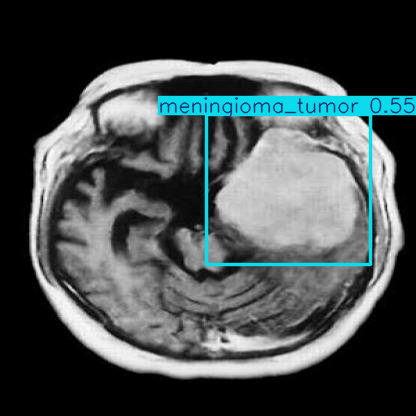

In [ ]:
from google.colab import files

# Upload ek single image
uploaded = files.upload()

# Jo image upload hui hai uska naam leke run karo
results = model.predict(source=list(uploaded.keys())[0], save=True)

# Prediction dikhane ke liye
results[0].show()


In [ ]:
from ultralytics import YOLO

# apna trained model load karo
model = YOLO("runs/detect/train/weights/best.pt")

# valid set pe evaluation
metrics = model.val()


Ultralytics 8.3.189 🚀 Python-3.12.11 torch-2.8.0+cu126 CPU (Intel Xeon 2.20GHz)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 449.5±232.9 MB/s, size: 16.4 KB)
val: Scanning /content/Brain-Tumor-Detection-2/valid/labels.cache... 45 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 45/45 36542.8it/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 0.22it/s 13.6s
                   all         45         45      0.807      0.719      0.807      0.351
          glioma-tumor         16         16      0.717      0.688      0.769      0.258
      meningioma_tumor         22         22      0.943      0.755      0.899      0.438
       pituitary_tumor          7          7       0.76      0.714      0.753      0.356
Speed: 7.2ms preprocess, 285.3ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to runs/detect/val


In [ ]:
from ultralytics import YOLO

# apna trained model load karo
model = YOLO("runs/detect/train/weights/best.pt")

# validation run
metrics = model.val()


Ultralytics 8.3.189 🚀 Python-3.12.11 torch-2.8.0+cu126 CPU (Intel Xeon 2.20GHz)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 660.6±244.2 MB/s, size: 20.0 KB)
val: Scanning /content/Brain-Tumor-Detection-2/valid/labels.cache... 45 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 45/45 37892.7it/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 0.24it/s 12.6s
                   all         45         45      0.807      0.719      0.807      0.351
          glioma-tumor         16         16      0.717      0.688      0.769      0.258
      meningioma_tumor         22         22      0.943      0.755      0.899      0.438
       pituitary_tumor          7          7       0.76      0.714      0.753      0.356
Speed: 3.1ms preprocess, 266.1ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to runs/detect/val2
